# 01 · Data Understanding — Fact tables & dimensiones

**Proyecto:** predicción de *silent churn* de vendedoras de Glamour Perú (venta directa por catálogo).

Este notebook es el **primer paso del CRISP-DM**: *Data Understanding* sobre la
data **cruda** del data warehouse, **antes** de construir cualquier dataset de
entrenamiento. El objetivo no es modelar todavía, sino **conocer la materia prima**:
qué tablas hay, cómo se relacionan, qué calidad tienen y qué señal pueden aportar.

## Esquema: estrella (star schema)

El DW sigue un modelo dimensional clásico: dos **tablas de hechos** (los eventos
transaccionales) rodeadas de **dimensiones** (el contexto descriptivo).

- **`fact_pedidos`** — cabecera del pedido: un pedido que una vendedora coloca en una
  campaña, con montos totales. Grano = **un pedido**.
- **`fact_pedidos_detalle`** — líneas del pedido: qué productos y cantidades componen
  cada pedido. Grano = **una línea (producto) dentro de un pedido**.
- **Dimensiones** — `dim_vendedor`, `dim_coordinadora`, `dim_campana`, `dim_producto`,
  `dim_ubicacion`, `dim_fecha`: atributos descriptivos que dan contexto a los hechos.

## Qué vamos a inspeccionar

Para cada tabla, las preguntas estándar de *data understanding*:

1. **Forma y tipos** — filas, columnas, dtypes.
2. **Completitud** — % de nulos por columna.
3. **Cardinalidad** — ¿es clave única? ¿cuántos valores distintos por categoría?
4. **Distribuciones** — numéricas (rango, outliers) y categóricas (frecuencias).
5. **Integridad referencial** — ¿las FKs de los hechos existen en las dimensiones?
6. **Cobertura temporal** — rango de fechas, volumen por año/mes.
7. **Calidad** — duplicados, valores imposibles, montos negativos, etc.



## 0 · Setup

Cargamos las 8 tablas desde los CSV crudos en `data/raw/fact_tables_&_dimensions/`
(extraídos de BigQuery con `00_dataset_construction/extract_raw_tables.py`).
Trabajar sobre CSV locales hace el EDA reproducible offline y rápido de iterar.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

# Este notebook vive en clean/01_data_understanding/.
# Buscamos hacia arriba la carpeta de data cruda.
MARKER = Path("data") / "raw" / "fact_tables_&_dimensions"
base = Path.cwd()
while not (base / MARKER).exists() and base != base.parent:
    base = base.parent
RAW = base / MARKER
assert RAW.exists(), f"No encuentro {MARKER} — corré extract_raw_tables.py. Busqué desde {Path.cwd()}"
print("Leyendo CSV de:", RAW)

Leyendo CSV de: /home/carlos/projects/glamour/customer-churn-prediction/clean/data/raw/fact_tables_&_dimensions


In [2]:
TABLES = [
    "dim_campana", "dim_coordinadora", "dim_fecha", "dim_producto",
    "dim_ubicacion", "dim_vendedor", "fact_pedidos", "fact_pedidos_detalle",
]
# Parseo de fechas conocido por el schema.
# Nota: dim_vendedor y dim_coordinadora ya no traen `edad` (FLOAT64) sino
# `fecha_nacimiento` (DATE); la edad se deriva donde haga falta.
DATE_COLS = {
    "dim_campana": ["fecha_inicio", "fecha_fin"],
    "dim_fecha": ["date"],
    "dim_vendedor": ["fecha_ingreso", "fecha_nacimiento"],
    "dim_coordinadora": ["fecha_nacimiento"],
}
dfs = {}
for t in TABLES:
    dfs[t] = pd.read_csv(RAW / f"{t}.csv", parse_dates=DATE_COLS.get(t, []))

# Acceso cómodo por nombre
dim_campana, dim_coordinadora, dim_fecha = dfs["dim_campana"], dfs["dim_coordinadora"], dfs["dim_fecha"]
dim_producto, dim_ubicacion, dim_vendedor = dfs["dim_producto"], dfs["dim_ubicacion"], dfs["dim_vendedor"]
fact_pedidos, fact_pedidos_detalle = dfs["fact_pedidos"], dfs["fact_pedidos_detalle"]

print(f"{len(TABLES)} tablas cargadas")

8 tablas cargadas


### Helpers de perfilado

Funciones reutilizables para no repetir código en cada tabla.


In [3]:
def overview(df, name):
    """Forma, memoria y dtypes."""
    print(f"=== {name} ===")
    print(f"filas: {len(df):,}   columnas: {df.shape[1]}   memoria: {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
    return df.dtypes.to_frame("dtype")


def profile(df):
    """Tabla de perfilado por columna: dtype, nulos, únicos, ejemplo."""
    rows = []
    n = len(df)
    for c in df.columns:
        s = df[c]
        rows.append({
            "columna": c,
            "dtype": str(s.dtype),
            "n_nulos": int(s.isna().sum()),
            "%_nulos": round(100 * s.isna().mean(), 2),
            "n_unicos": int(s.nunique(dropna=True)),
            "%_unicos": round(100 * s.nunique(dropna=True) / n, 2) if n else 0,
            "ejemplo": s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(rows).set_index("columna")


def is_unique_key(df, cols):
    """¿La combinación de columnas es clave única (sin nulos, sin duplicados)?"""
    cols = [cols] if isinstance(cols, str) else cols
    sub = df[cols]
    return {"cols": cols, "duplicados": int(sub.duplicated().sum()),
            "nulos": int(sub.isna().any(axis=1).sum()), "es_clave": bool(sub.duplicated().sum() == 0 and not sub.isna().any().any())}


def fk_integrity(fact, fkey, dim, dkey, name):
    """% de filas del hecho cuya FK NO existe en la dimensión (orphans)."""
    valid = set(dim[dkey].dropna().unique())
    present = fact[fkey].notna()
    orphan = fact.loc[present, fkey].apply(lambda v: v not in valid)
    n_orphan = int(orphan.sum())
    print(f"{name}: {fact[fkey].isna().sum():,} nulos | "
          f"{n_orphan:,} huérfanos ({100*n_orphan/max(present.sum(),1):.2f}% de los no-nulos)")
    return fact.loc[present][orphan]

## 1 · Panorama global

Tamaño y completitud de las 8 tablas de un vistazo, para situarnos antes de
entrar al detalle.


In [4]:
resumen = pd.DataFrame([
    {"tabla": t, "filas": len(dfs[t]), "columnas": dfs[t].shape[1],
     "%_celdas_nulas": round(100 * dfs[t].isna().to_numpy().mean(), 2)}
    for t in TABLES
]).sort_values("filas", ascending=False).set_index("tabla")
resumen

,filas,columnas,%_celdas_nulas
tabla,,,
fact_pedidos_detalle,342002,9,0.01
fact_pedidos,57434,10,0.02
dim_vendedor,21644,10,7.28
dim_fecha,7670,6,0.00
dim_producto,5018,4,0.00
dim_ubicacion,1864,5,0.00
dim_campana,158,7,0.00
dim_coordinadora,7,4,14.29


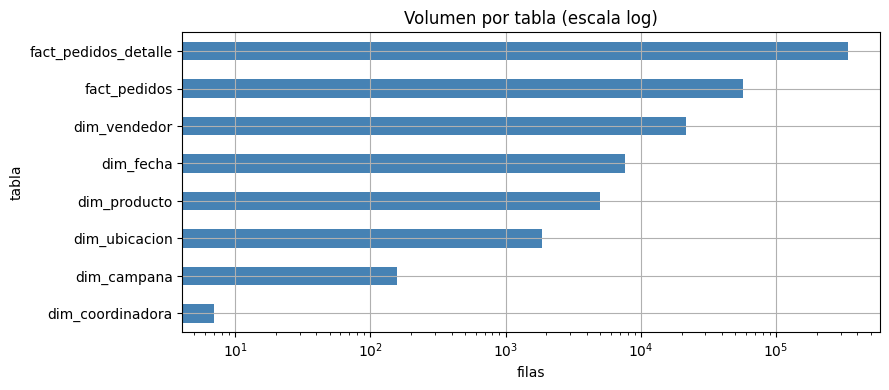

In [5]:
ax = resumen["filas"].sort_values().plot.barh(logx=True, color="steelblue")
ax.set_title("Volumen por tabla (escala log)")
ax.set_xlabel("filas")
plt.tight_layout()
plt.show()

## 2 · `dim_vendedor` — la entidad central (el sujeto del churn)

`dim_vendedor` describe a cada vendedora: es **la entidad sobre la que predecimos
churn**. Cada fila es una vendedora única (`id_vendedor`). Atributos clave:
`tipo_vendedor`, `fecha_nacimiento` (de la que derivamos la edad), `csexpersona`,
ubicación (`ccodubigeo`), coordinadora asignada (`id_coordinadora`) y `fecha_ingreso`.

> **Nota de schema:** la tabla ya **no** trae una columna `edad` (FLOAT64); ahora
> trae `fecha_nacimiento` (DATE). La edad se calcula a demanda como
> `hoy − fecha_nacimiento`.

⚠️ **Riesgo conocido:** varios atributos son un *snapshot* actual (SCD tipo 1), no
histórico — `id_coordinadora` y `tipo_vendedor` reflejan el estado de hoy, no el del
momento de cada pedido. (`fecha_nacimiento` sí es estable en el tiempo, pero la edad
*derivada* depende de la fecha de corte.) Lo dejamos anotado para el feature engineering.

In [6]:
overview(dfs["dim_vendedor"], "dim_vendedor")

=== dim_vendedor ===
filas: 21,644   columnas: 10   memoria: 7.3 MB


,dtype
id_vendedor,int64
nombre_vendedor,object
csexpersona,object
fecha_nacimiento,datetime64[ns]
ccodubigeo,object
nmovil,object
ccodrelacion,int64
id_coordinadora,int64
fecha_ingreso,datetime64[ns]
tipo_vendedor,object


In [7]:
profile(dfs["dim_vendedor"])

,dtype,n_nulos,%_nulos,n_unicos,%_unicos,ejemplo
columna,,,,,,
id_vendedor,int64,0,0.00,21644,100.00,19724125
nombre_vendedor,object,0,0.00,21560,99.61,OLGA DORIS MALCA YENQUE
csexpersona,object,0,0.00,4,0.02,F
fecha_nacimiento,datetime64[ns],12635,58.38,6614,30.56,1965-04-15 00:00:00
ccodubigeo,object,12,0.06,668,3.09,PE210016
nmovil,object,3104,14.34,17769,82.10,950426857
ccodrelacion,int64,0,0.00,834,3.85,0
id_coordinadora,int64,0,0.00,8,0.04,0
fecha_ingreso,datetime64[ns],1,0.00,2950,13.63,2016-12-15 00:00:00


In [8]:
print("¿id_vendedor es clave única?", is_unique_key(dim_vendedor, "id_vendedor"))
print()
for c in ["tipo_vendedor", "csexpersona", "ccodrelacion"]:
    print(f"--- {c} ---")
    print(dim_vendedor[c].value_counts(dropna=False).head(10), "\n")

¿id_vendedor es clave única? {'cols': ['id_vendedor'], 'duplicados': 0, 'nulos': 0, 'es_clave': True}

--- tipo_vendedor ---
tipo_vendedor
Asesora    20580
Líder       1064
Name: count, dtype: int64 

--- csexpersona ---
csexpersona
F    21176
M      291
1      176
2        1
Name: count, dtype: int64 

--- ccodrelacion ---
ccodrelacion
0           9362
19722010     490
19722072     482
19727244     383
19732017     321
19725581     271
19722029     191
19722097     181
19722082     166
19721994     155
Name: count, dtype: int64 



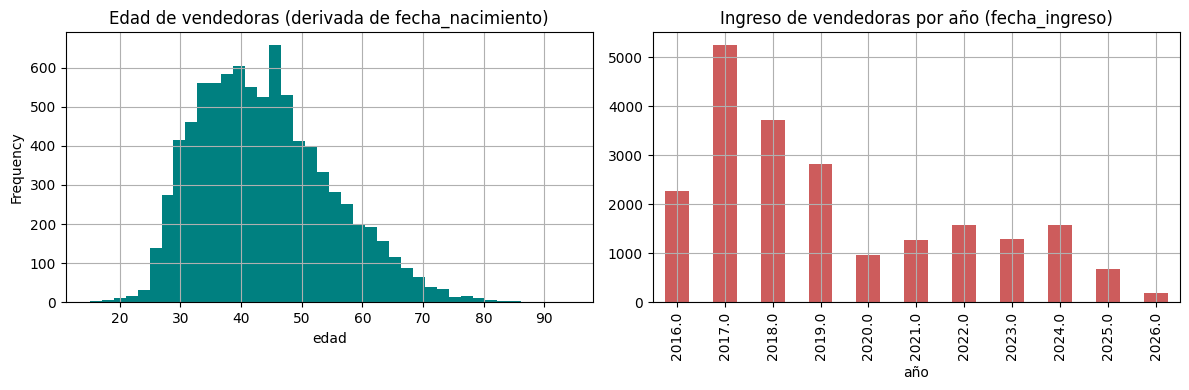

fecha_nacimiento: 12,635 nulos (58.4%) | rango 1860-07-12 -> 2224-12-27
edad derivada — describe:
 count    8542.000000
mean       44.007889
std        10.935945
min        15.044490
25%        35.614648
50%        42.941821
75%        50.991102
max        94.042437
Name: fecha_nacimiento, dtype: float64


In [9]:
# La edad no viene en el schema: la derivamos de fecha_nacimiento.
hoy = pd.Timestamp.now().normalize()
edad = (hoy - dim_vendedor["fecha_nacimiento"]).dt.days / 365.25
edad = edad.where(edad.between(15, 95))  # descartar fechas de nacimiento implausibles

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
edad.dropna().plot.hist(bins=40, ax=ax[0], color="teal")
ax[0].set_title("Edad de vendedoras (derivada de fecha_nacimiento)"); ax[0].set_xlabel("edad")
dim_vendedor["fecha_ingreso"].dt.year.value_counts().sort_index().plot.bar(ax=ax[1], color="indianred")
ax[1].set_title("Ingreso de vendedoras por año (fecha_ingreso)"); ax[1].set_xlabel("año")
plt.tight_layout(); plt.show()

nn = dim_vendedor["fecha_nacimiento"].isna()
print(f"fecha_nacimiento: {nn.sum():,} nulos ({100*nn.mean():.1f}%) | "
      f"rango {dim_vendedor['fecha_nacimiento'].min().date()} -> {dim_vendedor['fecha_nacimiento'].max().date()}")
print("edad derivada — describe:\n", edad.describe())

## 3 · `dim_coordinadora` — líderes de zona (7 registros)

`dim_coordinadora` es la dimensión más pequeña (7 filas). Cada coordinadora lidera
a un grupo de vendedoras. Útil como variable de **contexto organizacional**.


In [10]:
overview(dfs["dim_coordinadora"], "dim_coordinadora")

=== dim_coordinadora ===
filas: 7   columnas: 4   memoria: 0.0 MB


,dtype
id_coordinadora,int64
nombre_coordinadora,object
estado,int64
fecha_nacimiento,datetime64[ns]


In [11]:
profile(dfs["dim_coordinadora"])

,dtype,n_nulos,%_nulos,n_unicos,%_unicos,ejemplo
columna,,,,,,
id_coordinadora,int64,0,0.00,7,100.00,19721985
nombre_coordinadora,object,0,0.00,7,100.00,DIRECTA2
estado,int64,0,0.00,2,28.57,1
fecha_nacimiento,datetime64[ns],4,57.14,2,28.57,1979-01-01 00:00:00


In [12]:
dim_coordinadora

,id_coordinadora,nombre_coordinadora,estado,fecha_nacimiento
0,19721985,DIRECTA2,1,NaT
1,19721984,YULI,1,NaT
2,19738624,NELLY,1,NaT
3,19735959,ELENA,1,NaT
4,19721983,MARISOL,1,1979-01-01
5,19721986,LETTIA,1,1979-01-01
6,19729612,PATRICIA,0,2018-01-01


## 4 · `dim_campana` — el calendario comercial

`dim_campana` define las campañas de venta (catálogos). Históricamente la unidad
temporal del negocio, pero **dejó de ser consistente desde mediados de 2025**
(de 1 campaña/mes a 2-3/mes simultáneas). Acá verificamos esa irregularidad temporal.


In [13]:
overview(dfs["dim_campana"], "dim_campana")

=== dim_campana ===
filas: 158   columnas: 7   memoria: 0.0 MB


,dtype
id_campana,int64
nombre_campana,object
estado,int64
fecha_inicio,datetime64[ns]
fecha_fin,datetime64[ns]
anio,int64
numero_campana,int64


In [14]:
profile(dfs["dim_campana"])

,dtype,n_nulos,%_nulos,n_unicos,%_unicos,ejemplo
columna,,,,,,
id_campana,int64,0,0.0,158,100.00,16101
nombre_campana,object,0,0.0,157,99.37,Glamour 2016-01
estado,int64,0,0.0,2,1.27,0
fecha_inicio,datetime64[ns],0,0.0,154,97.47,2016-11-02 00:00:00
fecha_fin,datetime64[ns],0,0.0,149,94.30,2016-12-04 00:00:00
anio,int64,0,0.0,11,6.96,2016
numero_campana,int64,0,0.0,158,100.00,1


¿id_campana es clave única? {'cols': ['id_campana'], 'duplicados': 0, 'nulos': 0, 'es_clave': True}

estado:
 estado
0    155
1      3
Name: count, dtype: int64


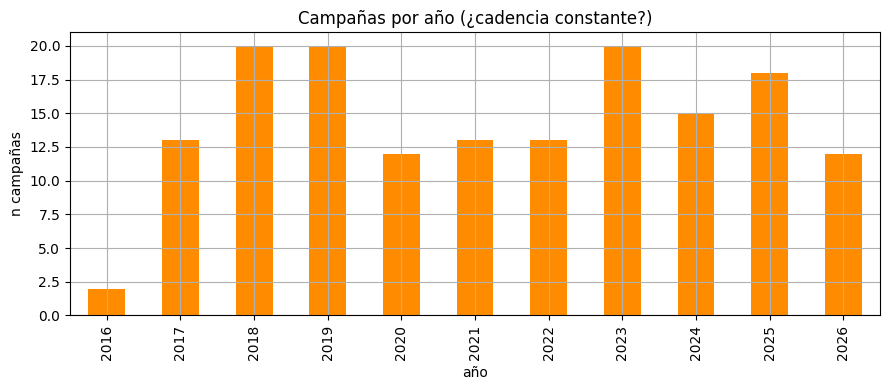

anio
2016     2
2017    13
2018    20
2019    20
2020    12
2021    13
2022    13
2023    20
2024    15
2025    18
2026    12
dtype: int64

In [15]:
print("¿id_campana es clave única?", is_unique_key(dim_campana, "id_campana"))
print("\nestado:\n", dim_campana["estado"].value_counts(dropna=False))
camp_por_anio = dim_campana.groupby("anio").size()
ax = camp_por_anio.plot.bar(color="darkorange")
ax.set_title("Campañas por año (¿cadencia constante?)"); ax.set_ylabel("n campañas"); ax.set_xlabel("año")
plt.tight_layout(); plt.show()
camp_por_anio

## 5 · `dim_producto` — catálogo de productos

`dim_producto` es el catálogo: cada producto con su `categoria` y `subcategoria`.
Permite medir **diversidad de producto** por vendedora (señal de engagement).


In [16]:
overview(dfs["dim_producto"], "dim_producto")

=== dim_producto ===
filas: 5,018   columnas: 4   memoria: 1.3 MB


,dtype
id_producto,object
nombre_producto,object
categoria,object
subcategoria,object


In [17]:
profile(dfs["dim_producto"])

,dtype,n_nulos,%_nulos,n_unicos,%_unicos,ejemplo
columna,,,,,,
id_producto,object,0,0.0,5018,100.00,121728180607094100VEAM
nombre_producto,object,0,0.0,4998,99.60,b. anillo herat j-01002
categoria,object,0,0.0,10,0.20,Accesorios
subcategoria,object,0,0.0,56,1.12,Anillos


¿id_producto es clave única? {'cols': ['id_producto'], 'duplicados': 0, 'nulos': 0, 'es_clave': True}

Top categorías:
 categoria
Ropa                    4195
Accesorios               373
Sin clasificar           248
Electrodomésticos         69
Perfumes                  48
Maquillaje                46
Regalos / Incentivos      17
Aceites Esenciales        11
Hogar                     10
Tecnología                 1
Name: count, dtype: int64


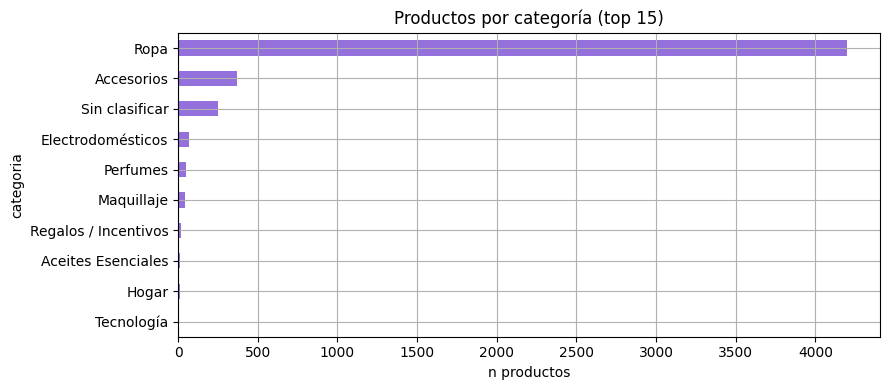

In [18]:
print("¿id_producto es clave única?", is_unique_key(dim_producto, "id_producto"))
print("\nTop categorías:\n", dim_producto["categoria"].value_counts(dropna=False).head(15))
ax = dim_producto["categoria"].value_counts().head(15).sort_values().plot.barh(color="mediumpurple")
ax.set_title("Productos por categoría (top 15)"); ax.set_xlabel("n productos")
plt.tight_layout(); plt.show()

## 6 · `dim_ubicacion` — geografía (ubigeo Perú)

`dim_ubicacion` mapea el código `ccodubigeo` a `distrito` / `provincia` /
`departamento`. ⚠️ `distrito` tiene cardinalidad alta (riesgo de identificar
individuos) — conviene usar agregaciones como `provincia` y `departamento`.


In [19]:
overview(dfs["dim_ubicacion"], "dim_ubicacion")

=== dim_ubicacion ===
filas: 1,864   columnas: 5   memoria: 0.4 MB


,dtype
ccodubigeo,object
id_ubicacion,int64
distrito,object
provincia,object
departamento,object


In [20]:
profile(dfs["dim_ubicacion"])

,dtype,n_nulos,%_nulos,n_unicos,%_unicos,ejemplo
columna,,,,,,
ccodubigeo,object,0,0.0,1864,100.00,PE020110
id_ubicacion,int64,0,0.0,1857,99.62,20109
distrito,object,0,0.0,1678,90.02,Pampas
provincia,object,0,0.0,221,11.86,Huaraz
departamento,object,0,0.0,39,2.09,Ancash


¿ccodubigeo es clave única? {'cols': ['ccodubigeo'], 'duplicados': 0, 'nulos': 0, 'es_clave': True}
departamento: 39 valores únicos
provincia: 221 valores únicos
distrito: 1678 valores únicos


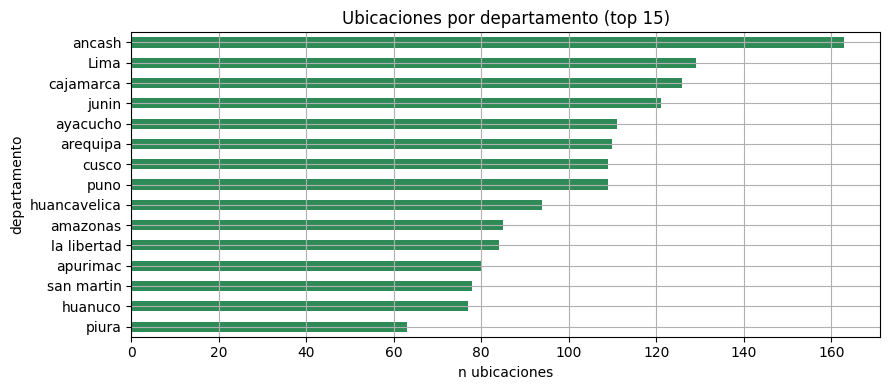

In [21]:
print("¿ccodubigeo es clave única?", is_unique_key(dim_ubicacion, "ccodubigeo"))
for c in ["departamento", "provincia", "distrito"]:
    print(f"{c}: {dim_ubicacion[c].nunique()} valores únicos")
ax = dim_ubicacion["departamento"].value_counts().head(15).sort_values().plot.barh(color="seagreen")
ax.set_title("Ubicaciones por departamento (top 15)"); ax.set_xlabel("n ubicaciones")
plt.tight_layout(); plt.show()

## 7 · `dim_fecha` — dimensión de tiempo

`dim_fecha` es el calendario que conecta ambos hechos vía `id_fecha`. Cada fila
es un día con sus atributos (`calendaryear`, `calendarmonth`, etc.). Permite agregar
pedidos a **mes calendario**.


In [22]:
overview(dfs["dim_fecha"], "dim_fecha")

=== dim_fecha ===
filas: 7,670   columnas: 6   memoria: 0.4 MB


,dtype
date,datetime64[ns]
id_fecha,int64
calendaryear,int64
calendarmonth,int64
calendardayinmonth,int64
calendarquarter,int64


In [23]:
profile(dfs["dim_fecha"])

,dtype,n_nulos,%_nulos,n_unicos,%_unicos,ejemplo
columna,,,,,,
date,datetime64[ns],0,0.0,7670,100.00,2010-01-01 00:00:00
id_fecha,int64,0,0.0,7670,100.00,1
calendaryear,int64,0,0.0,21,0.27,2010
calendarmonth,int64,0,0.0,12,0.16,1
calendardayinmonth,int64,0,0.0,31,0.40,1
calendarquarter,int64,0,0.0,4,0.05,1


In [24]:
print("¿id_fecha es clave única?", is_unique_key(dim_fecha, "id_fecha"))
print("¿date es clave única?", is_unique_key(dim_fecha, "date"))
print(f"\nRango de fechas: {dim_fecha['date'].min().date()} -> {dim_fecha['date'].max().date()}")
print(f"Años cubiertos: {dim_fecha['calendaryear'].min()} - {dim_fecha['calendaryear'].max()}")

¿id_fecha es clave única? {'cols': ['id_fecha'], 'duplicados': 0, 'nulos': 0, 'es_clave': True}
¿date es clave única? {'cols': ['date'], 'duplicados': 0, 'nulos': 0, 'es_clave': True}

Rango de fechas: 2010-01-01 -> 2030-12-31
Años cubiertos: 2010 - 2030


## 8 · `fact_pedidos` — cabeceras de pedido

El hecho central. Cada fila es **un pedido** colocado por una vendedora en una
campaña, con `monto_total_pedido` y `monto_pagado`. Aquí vive la señal RFM
(recencia / frecuencia / monetario) que alimenta un modelo de churn.


In [25]:
overview(fact_pedidos, "fact_pedidos")

=== fact_pedidos ===
filas: 57,434   columnas: 10   memoria: 7.4 MB


,dtype
id_pedido,int64
id_campana,int64
id_vendedor,int64
id_fecha,int64
id_coordinadora,float64
id_ubicacion,float64
monto_total_pedido,float64
monto_pagado,float64
es_nueva_vendedora,int64
tipo,object


In [26]:
profile(fact_pedidos)

,dtype,n_nulos,%_nulos,n_unicos,%_unicos,ejemplo
columna,,,,,,
id_pedido,int64,0,0.00,57434,100.00,1610100297
id_campana,int64,0,0.00,156,0.27,16101
id_vendedor,int64,0,0.00,11925,20.76,19722454
id_fecha,int64,0,0.00,3324,5.79,2500
id_coordinadora,float64,71,0.12,8,0.01,0.0
id_ubicacion,float64,72,0.13,537,0.93,80101.0
monto_total_pedido,float64,0,0.00,11185,19.47,161.98
monto_pagado,float64,0,0.00,22363,38.94,121.49
es_nueva_vendedora,int64,0,0.00,2,0.00,0


In [27]:
print("¿id_pedido es clave única?", is_unique_key(fact_pedidos, "id_pedido"))
print("\ntipo:\n", fact_pedidos["tipo"].value_counts(dropna=False))
print("\nes_nueva_vendedora:\n", fact_pedidos["es_nueva_vendedora"].value_counts(dropna=False))
print("\nmonto_total_pedido — describe:\n", fact_pedidos["monto_total_pedido"].describe())
neg = (fact_pedidos["monto_total_pedido"] < 0).sum()
cero = (fact_pedidos["monto_total_pedido"] == 0).sum()
print(f"\nMontos negativos: {neg:,} | montos en cero: {cero:,}")
print("¿monto_pagado > monto_total? (filas):",
      int((fact_pedidos['monto_pagado'] > fact_pedidos['monto_total_pedido']).sum()))

¿id_pedido es clave única? {'cols': ['id_pedido'], 'duplicados': 0, 'nulos': 0, 'es_clave': True}

tipo:
 tipo
Catalogo    51129
Directo      6305
Name: count, dtype: int64

es_nueva_vendedora:
 es_nueva_vendedora
0    45159
1    12275
Name: count, dtype: int64



monto_total_pedido — describe:
 count    57434.000000
mean       357.614649
std        295.180648
min          0.000000
25%        200.972500
50%        308.925000
75%        432.772500
max       8284.840000
Name: monto_total_pedido, dtype: float64

Montos negativos: 0 | montos en cero: 2,748
¿monto_pagado > monto_total? (filas): 1671


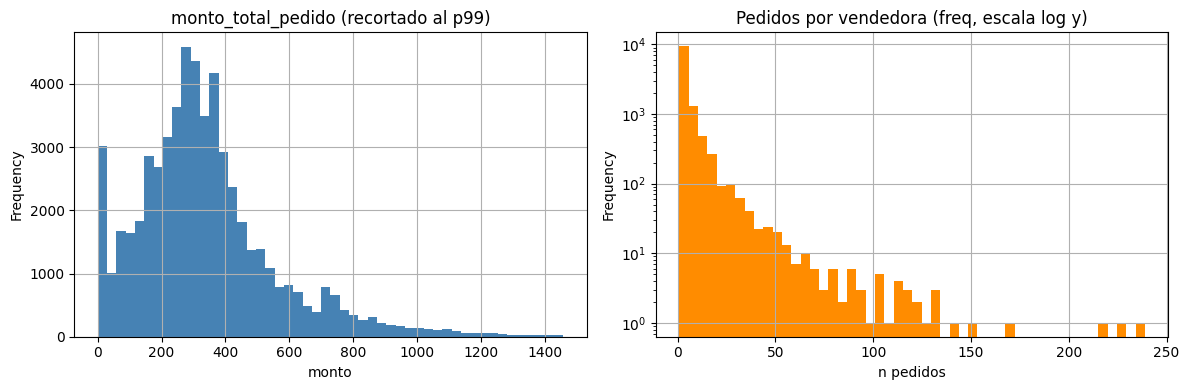

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
fact_pedidos.loc[fact_pedidos["monto_total_pedido"].between(0, fact_pedidos["monto_total_pedido"].quantile(0.99)),
                 "monto_total_pedido"].plot.hist(bins=50, ax=ax[0], color="steelblue")
ax[0].set_title("monto_total_pedido (recortado al p99)"); ax[0].set_xlabel("monto")
fact_pedidos.groupby("id_vendedor").size().plot.hist(bins=50, ax=ax[1], color="darkorange", log=True)
ax[1].set_title("Pedidos por vendedora (freq, escala log y)"); ax[1].set_xlabel("n pedidos")
plt.tight_layout(); plt.show()

### 8.1 · Integridad referencial de `fact_pedidos`

Verificamos que las claves foráneas del hecho existan en sus dimensiones. Filas
huérfanas (FK sin match) indicarían problemas de carga del DW.


In [29]:
_ = fk_integrity(fact_pedidos, "id_vendedor", dim_vendedor, "id_vendedor", "id_vendedor -> dim_vendedor")
_ = fk_integrity(fact_pedidos, "id_campana", dim_campana, "id_campana", "id_campana -> dim_campana")
_ = fk_integrity(fact_pedidos, "id_coordinadora", dim_coordinadora, "id_coordinadora", "id_coordinadora -> dim_coordinadora")
_ = fk_integrity(fact_pedidos, "id_fecha", dim_fecha, "id_fecha", "id_fecha -> dim_fecha")

id_vendedor -> dim_vendedor: 0 nulos | 71 huérfanos (0.12% de los no-nulos)
id_campana -> dim_campana: 0 nulos | 0 huérfanos (0.00% de los no-nulos)
id_coordinadora -> dim_coordinadora: 71 nulos | 79 huérfanos (0.14% de los no-nulos)
id_fecha -> dim_fecha: 0 nulos | 0 huérfanos (0.00% de los no-nulos)


### 8.2 · Cobertura temporal de pedidos

Unimos `fact_pedidos` con `dim_fecha` para ver el volumen de pedidos en el tiempo.
Esto define la ventana de datos disponible para entrenar.


Rango de pedidos: 2016-11-02 -> 2026-05-31


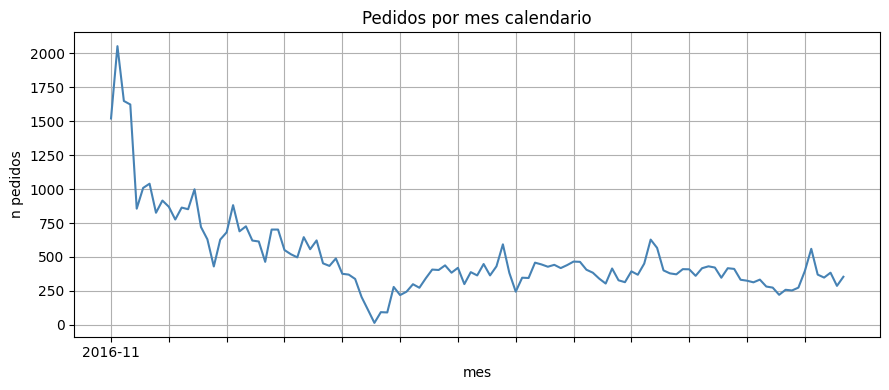

In [30]:
ped = fact_pedidos.merge(dim_fecha[["id_fecha", "date", "calendaryear", "calendarmonth"]],
                         on="id_fecha", how="left")
ped["anio_mes"] = ped["date"].dt.to_period("M").astype(str)
print(f"Rango de pedidos: {ped['date'].min().date()} -> {ped['date'].max().date()}")
serie = ped.groupby("anio_mes").size()
ax = serie.plot(color="steelblue")
ax.set_title("Pedidos por mes calendario"); ax.set_ylabel("n pedidos"); ax.set_xlabel("mes")
ax.set_xticks(range(0, len(serie), max(len(serie)//12, 1)))
plt.tight_layout(); plt.show()

## 9 · `fact_pedidos_detalle` — líneas de pedido

El hecho de mayor grano: **una fila por producto dentro de un pedido**
(`id_pedido` × `id_pedido_detalle`). La suma de sus `importe_producto` debería
reconciliar con `monto_total_pedido` de la cabecera — lo verificamos.


In [31]:
overview(fact_pedidos_detalle, "fact_pedidos_detalle")

=== fact_pedidos_detalle ===
filas: 342,002   columnas: 9   memoria: 46.2 MB


,dtype
id_pedido,int64
id_campana,int64
id_vendedor,int64
id_fecha,int64
id_ubicacion,float64
id_pedido_detalle,int64
id_producto,object
cantidad,float64
importe_producto,float64


In [32]:
profile(fact_pedidos_detalle)

,dtype,n_nulos,%_nulos,n_unicos,%_unicos,ejemplo
columna,,,,,,
id_pedido,int64,0,0.0,57432,16.79,1610100121
id_campana,int64,0,0.0,156,0.05,16101
id_vendedor,int64,0,0.0,11925,3.49,19722454
id_fecha,int64,0,0.0,3324,0.97,2498
id_ubicacion,float64,355,0.1,537,0.16,10101.0
id_pedido_detalle,int64,0,0.0,342002,100.00,1018
id_producto,object,0,0.0,5273,1.54,121728161025163329GRP5
cantidad,float64,0,0.0,41,0.01,1.0
importe_producto,float64,0,0.0,866,0.25,95.99


In [33]:
print("¿(id_pedido, id_pedido_detalle) es clave única?",
      is_unique_key(fact_pedidos_detalle, ["id_pedido", "id_pedido_detalle"]))
print("\ncantidad — describe:\n", fact_pedidos_detalle["cantidad"].describe())
print("\nimporte_producto — describe:\n", fact_pedidos_detalle["importe_producto"].describe())
neg_c = (fact_pedidos_detalle["cantidad"] <= 0).sum()
neg_i = (fact_pedidos_detalle["importe_producto"] < 0).sum()
print(f"\ncantidad <= 0: {neg_c:,} | importe_producto < 0: {neg_i:,}")
print("Líneas por pedido (describe):\n",
      fact_pedidos_detalle.groupby("id_pedido").size().describe())

¿(id_pedido, id_pedido_detalle) es clave única? {'cols': ['id_pedido', 'id_pedido_detalle'], 'duplicados': 0, 'nulos': 0, 'es_clave': True}



cantidad — describe:
 count    342002.000000
mean          1.057932
std           0.917692
min          -4.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         200.000000
Name: cantidad, dtype: float64

importe_producto — describe:
 count    342002.000000
mean         59.381330
std          42.877931
min        -301.980000
25%          35.990000
50%          62.990000
75%          75.990000
max        5400.000000
Name: importe_producto, dtype: float64

cantidad <= 0: 1,530 | importe_producto < 0: 1,480
Líneas por pedido (describe):
 count    57432.000000
mean         5.954903
std          4.420690
min          1.000000
25%          3.000000
50%          5.000000
75%          8.000000
max         90.000000
dtype: float64


### 9.1 · Integridad referencial y reconciliación con la cabecera

Dos chequeos:
1. **FK a `dim_producto`** y consistencia de `id_pedido` con `fact_pedidos`.
2. **Reconciliación de montos**: ¿`sum(importe_producto)` por pedido ≈
   `monto_total_pedido`? Discrepancias revelarían descuentos, impuestos o
   problemas de integridad entre los dos hechos.


In [34]:
_ = fk_integrity(fact_pedidos_detalle, "id_producto", dim_producto, "id_producto", "id_producto -> dim_producto")

pedidos_cab = set(fact_pedidos["id_pedido"].unique())
det_sin_cab = (~fact_pedidos_detalle["id_pedido"].isin(pedidos_cab)).sum()
det_pedidos = set(fact_pedidos_detalle["id_pedido"].unique())
cab_sin_det = len(pedidos_cab - det_pedidos)
print(f"\nLíneas de detalle sin cabecera en fact_pedidos: {det_sin_cab:,}")
print(f"Cabeceras sin ninguna línea de detalle: {cab_sin_det:,}")

id_producto -> dim_producto: 0 nulos | 36,067 huérfanos (10.55% de los no-nulos)

Líneas de detalle sin cabecera en fact_pedidos: 0
Cabeceras sin ninguna línea de detalle: 2


Diferencia (cabecera - suma detalle) — describe:
 count    57432.000000
mean         4.017030
std         25.610756
min       -257.960000
25%          0.000000
50%          0.000000
75%          0.000000
max       1434.620000
Name: dif, dtype: float64

% de pedidos donde cabecera == suma detalle (tol 0.01): 95.6%


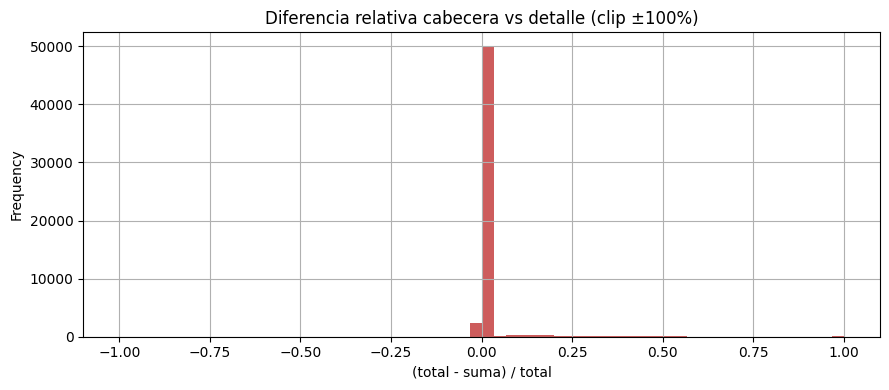

In [35]:
suma_det = fact_pedidos_detalle.groupby("id_pedido")["importe_producto"].sum().rename("suma_detalle")
recon = fact_pedidos[["id_pedido", "monto_total_pedido"]].merge(suma_det, on="id_pedido", how="inner")
recon["dif"] = recon["monto_total_pedido"] - recon["suma_detalle"]
recon["dif_rel"] = recon["dif"] / recon["monto_total_pedido"].replace(0, np.nan)
print("Diferencia (cabecera - suma detalle) — describe:\n", recon["dif"].describe())
match = (recon["dif"].abs() < 0.01).mean()
print(f"\n% de pedidos donde cabecera == suma detalle (tol 0.01): {100*match:.1f}%")
ax = recon["dif_rel"].clip(-1, 1).plot.hist(bins=60, color="indianred")
ax.set_title("Diferencia relativa cabecera vs detalle (clip ±100%)"); ax.set_xlabel("(total - suma) / total")
plt.tight_layout(); plt.show()

## 10 · Síntesis — hallazgos de data understanding

> **Completar tras correr el notebook.** Plantilla de conclusiones para volcar los
> números reales observados arriba:

**Tablas y grano**
- `fact_pedidos`: 1 fila por pedido (clave `id_pedido`). _N_ pedidos.
- `fact_pedidos_detalle`: 1 fila por línea (clave `id_pedido` × `id_pedido_detalle`). _N_ líneas.
- Dimensiones con clave única confirmada: …

**Calidad**
- Nulos relevantes: … (ej. `fecha_nacimiento` en `dim_vendedor`).
- Montos negativos / en cero: …
- Reconciliación cabecera ↔ detalle: __% de pedidos cuadran.

**Integridad referencial**
- FKs huérfanas detectadas: … (ej. `id_producto` en detalle).

**Cobertura temporal**
- Rango de pedidos: … → …
- Irregularidad de cadencia de campañas: …

### ⚠️ Problema de calidad: `fecha_nacimiento` (dim_vendedor)

La columna `fecha_nacimiento` (que reemplazó a la antigua `edad`) llega **muy sucia**:

- **58.4% nulos** (12 635 de 21 644 vendedoras sin fecha de nacimiento).
- **Rango imposible: 1860-07-12 → 2224-12-27** — hay fechas absurdas: vendedoras
  "nacidas" en el futuro (post-2224) o en el siglo XIX, físicamente imposibles para
  una vendedora activa.

**Implicancias para modelado:**
- La **edad** derivada de esta columna tendrá ruido fuerte y >50% de faltantes →
  baja confiabilidad como feature.
- Hay que **sanear** antes de usarla: filtrar a un rango plausible (p.ej. 15–95
  años de edad a la fecha de corte) e imputar/marcar los nulos, o directamente
  evaluar si la variable aporta señal suficiente para justificar su inclusión.
- Misma columna existe ahora en `dim_coordinadora` (verificar su calidad en §3).

**Riesgos para modelado (anotados)**
- `dim_vendedor` / `dim_coordinadora`: atributos snapshot SCD-1 (`id_coordinadora`,
  `tipo_vendedor`); la edad se deriva de `fecha_nacimiento` (DATE) a la fecha de corte.
- `fecha_nacimiento`: ~58% nulos + valores imposibles (ver bloque de calidad arriba).
- `distrito` / `ccodubigeo` alta cardinalidad → preferir `provincia` / `departamento`.
- `ccodrelacion` es un ID, no señal genuina.

**Próximo paso (CRISP-DM):** *Data Preparation* — construir el panel base
`(id_vendedor, mes)` agregando los hechos a mes calendario.